# Advanced Customization

In [69]:
# we will customize the plot as per our requirements    

In [70]:
# Import Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# now lets load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Final Cleaning
# sort by date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# convert job skills to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [71]:
# we want to look for only Data Engineer roles from job_title_short
df_DE= df[df['job_title_short'] == 'Data Engineer'].copy()

# extracting the month number from job_posting_date
df_DE['month_number'] = df_DE['job_posted_date'].dt.month

# exploding the job_skills column
df_DE_exploded = df_DE.explode('job_skills')

# pivoting the table by month number as index in ascdending order and skill names as coloumn
pivot_table = df_DE_exploded.pivot_table(index='month_number', columns='job_skills', aggfunc='size', fill_value=0)



# lets add a total row
pivot_table.loc['Total'] = pivot_table.sum()

# sort by Total row
pivot_table = pivot_table[pivot_table.loc['Total'].sort_values(ascending=False).index]

# drop total row
pivot_table = pivot_table.drop('Total')

# keep only top 5 skill columns
pivot_table = pivot_table.iloc[:, :5]

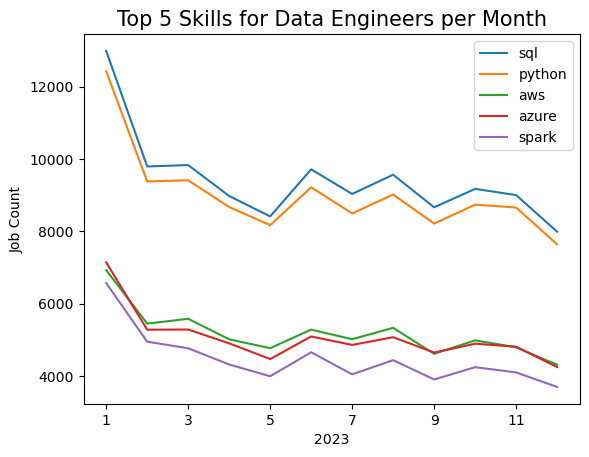

In [72]:
# final plotting with month name istead of month number
pivot_table.plot(kind='line')

# formatting
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.title('Top 5 Skills for Data Engineers per Month', fontsize=15)
plt.legend(title='')
plt.show()

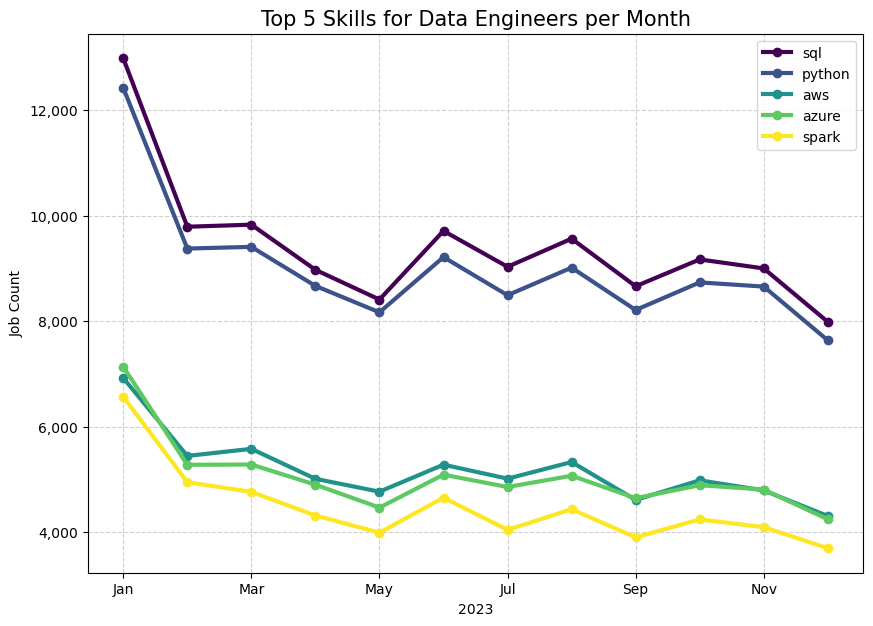

In [75]:
import matplotlib.pyplot as plt
import calendar
from matplotlib.ticker import StrMethodFormatter

# convert month numbers to month names (only if not already converted)
if isinstance(pivot_table.index[0], int):
    pivot_table.index = pivot_table.index.map(lambda x: calendar.month_abbr[x])

# plot
pivot_table.plot(
    kind='line',
    linewidth=3,
    colormap='viridis',
    marker='o',
    figsize=(10,7)
)

# formatting
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.title('Top 5 Skills for Data Engineers per Month', fontsize=15)

# add commas to y-axis numbers
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# add grid
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='')
plt.show()

# Customizing Scatter Plot

In [122]:
# Selecting Data Scientist for this plot
df_DE = df[df['job_title_short']=='Data Scientist'].copy()\

# Exploding the job_skills
df_exploded = df_DE.explode('job_skills')

# Using group by creating median and skill count column
df_stats = df_exploded.groupby('job_skills').agg(median_salary=('salary_year_avg','median'), skill_count=('job_skills','count'))

# sorting the values
df_stats = df_stats.sort_values(by='skill_count',ascending=False).head(25)

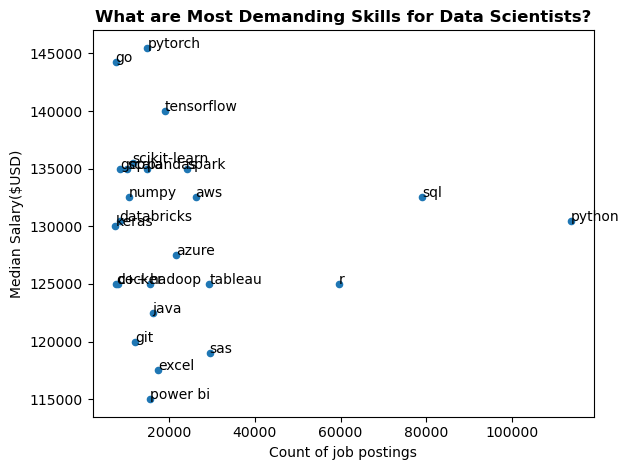

In [123]:
# now lets plot the chart
df_stats.plot(kind='scatter',y='median_salary',x='skill_count')

for i, txt in enumerate(df_stats.index):
    plt.text(df_stats['skill_count'].iloc[i], df_stats['median_salary'].iloc[i], txt)

# now lets format it
plt.xlabel('Count of job postings')
plt.ylabel('Median Salary($USD)')
plt.title('What are Most Demanding Skills for Data Scientists?',fontweight='bold')
plt.tight_layout()
plt.show()


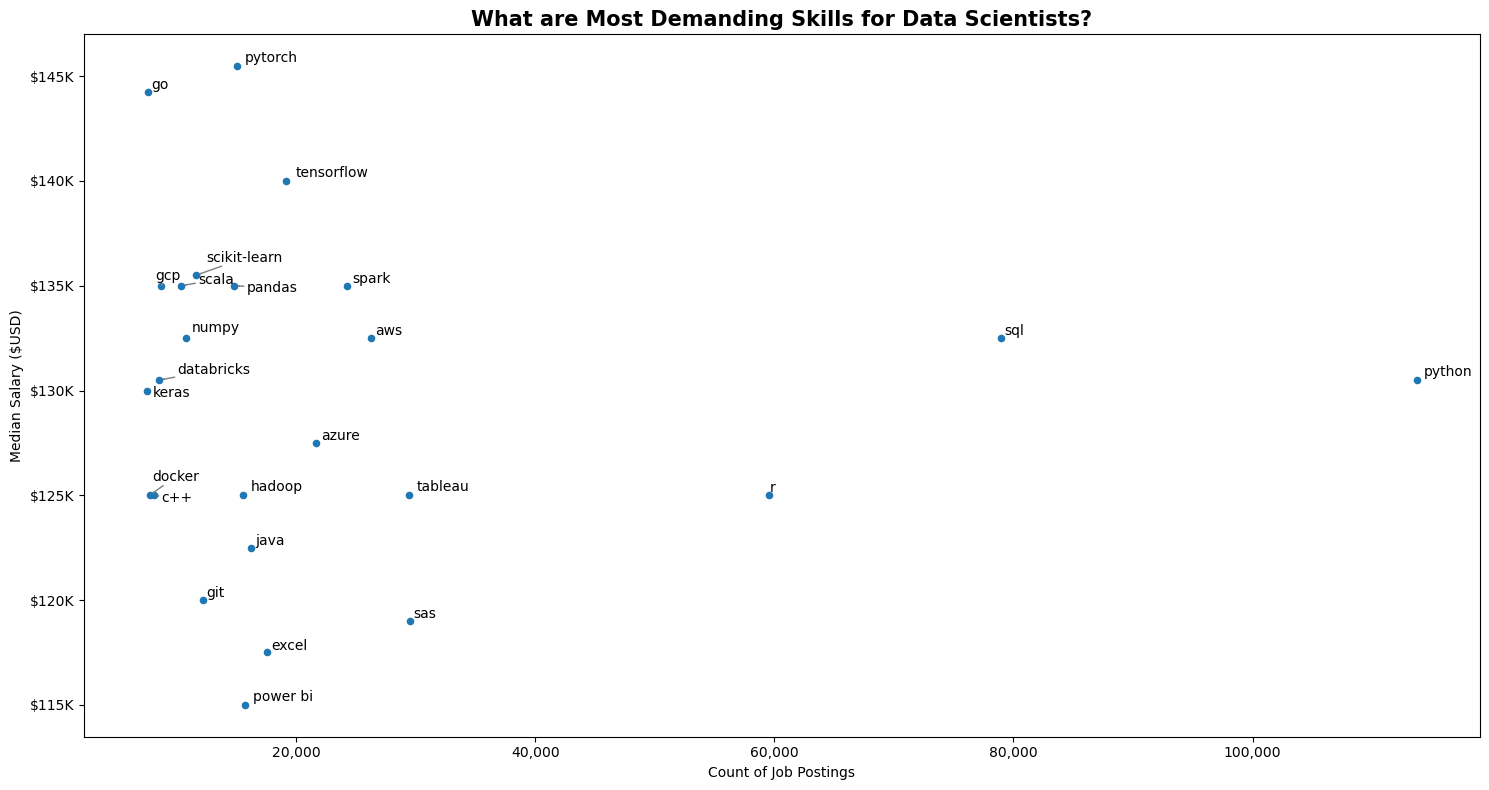

In [127]:
# fixing the overlapping
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, StrMethodFormatter

fig, ax = plt.subplots()

# scatter plot
df_stats.plot(kind='scatter', x='skill_count', y='median_salary', ax=ax, figsize=(15,8))

# store text objects
texts = []

for i, txt in enumerate(df_stats.index):
    texts.append(
        ax.text(
            df_stats['skill_count'].iloc[i],
            df_stats['median_salary'].iloc[i],
            txt
        )
    )

# adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

# format y-axis to $K
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y/1000:.0f}K'))

# format x-axis with commas
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# labels and title
ax.set_xlabel('Count of Job Postings')
ax.set_ylabel('Median Salary ($USD)')
ax.set_title('What are Most Demanding Skills for Data Scientists?', fontweight='bold', fontsize=15)

plt.tight_layout()
plt.show()